In [33]:
from mosep_analysis.data import config
from mosep_analysis.data.config import (
    TARGET_EXTENTS_VIF,
    TARGET_EXTENTS_VIF_SPLITS,
    ROOF_EXTENT,
    RING_OUTER,
    OBSTACLES_VIF,
    TARGET_DISTANCES,
    BAG_NAMES,
    SHIFT_DS_DATA,
)
from mosep_analysis.data import utils
from mosep_analysis.visualization import noise_plots
from moseplib.data.utils import flatten_multiindex, Limits
from moseplib.data import pointcloud_processing, pc_statistics, timeseries_processing

from datetime import timedelta
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.express as px

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR

from IPython.display import display, Latex

from pathlib import Path

## Load Met Data from Bagfile

In [4]:
PARQUET_DATA_DIR = config.PROCESSED_DATA_FOLDER

In [5]:
RESAMPLE_FREQ = "1min"
columns_and_aggregation = {
    ("precipitation", "intensity_hour_shifted"): "first",
    ("precipitation", "intensity_hour"): "first",
    ("precipitation", "differential"): "sum",
    ("precipitation", "total_precipitation_particles"): "sum",
    ("precipitation", "total_drops"): "sum",
    ("wind", "speed_avg"): "mean",
    ("temperature", "average"): "mean",
    ("humidity", "relative_avg"): "mean",
    ("pressure", "relative_avg"): "mean",
    ("radiation", "current"): "mean",
}

files = {nr: PARQUET_DATA_DIR / f"weather_df_{bag_name}.parquet" for nr, bag_name in BAG_NAMES.items()}

dfs = {}
df_relevant_all = {}
for nr, file in files.items():
    df = timeseries_processing.load_timeseries(safe_parquet=file)

    basename = "_".join(file.stem.split("_")[4:-1])
    dfs[basename] = df

    # Select relevant columns
    df_relevant = df.loc[:, columns_and_aggregation.keys()]

    columns = flatten_multiindex(df_relevant)
    # Resample to 1 minute intervals
    df_relevant = df_relevant.resample(RESAMPLE_FREQ).agg({".".join(k): v for k, v in columns_and_aggregation.items()})
    # Rename columns
    df_relevant.columns = columns_and_aggregation.keys()
    df_relevant_all[basename] = df_relevant

df = pd.concat(dfs, axis=0)
df_relevant = pd.concat(df_relevant_all, axis=0, names=["bag_name", "timestamp"])

Found parquet files, loading timeseries data...

Found parquet files, loading timeseries data...

Found parquet files, loading timeseries data...

Found parquet files, loading timeseries data...

Found parquet files, loading timeseries data...

...

Found parquet files, loading timeseries data...

Found parquet files, loading timeseries data...

Found parquet files, loading timeseries data...

Found parquet files, loading timeseries data...

Found parquet files, loading timeseries data...

In [6]:
df_relevant.to_csv(Path("/home/chg/mosep-analysis/data/3processed") / "weather_all.csv")

## Load PC data

In [18]:
# Per statistic, load the bag files as datasets into a list
ds_minutes_dict = {}
for nr, bag_name in BAG_NAMES.items():
    path = config.PROCESSED_DATA_FOLDER / f"rain_minutes_{bag_name}"
    ds_minutes = utils.load_or_resample_dataset(path)

    if SHIFT_DS_DATA.get(nr, 0) != 0:
        for stat, ds in ds_minutes.items():
            ds.timestamps = [date + timedelta(seconds=SHIFT_DS_DATA.get(nr, 0)) for date in ds.timestamps]

    for stat, ds in ds_minutes.items():
        if stat not in ds_minutes_dict:
            ds_minutes_dict[stat] = []
        ds_minutes_dict[stat].append(ds)

In [19]:
# Per statistic, transform list of datasets to single dataset
ds_minutes = dict.fromkeys(ds_minutes_dict)

for stat, lst in ds_minutes_dict.items():
    ds_minutes[stat] = lst[0]
    for ds in lst[1:]:
        ds_minutes[stat] = ds_minutes[stat].extend(ds)

In [48]:
# Limit point clouds to ring outer and apply obstacle exclusion
LIMIT_N_POINTS = Limits(n_max=20)

ds_minutes_roof = (
    ds_minutes["sum"]
    .apply(ROOF_EXTENT.apply_limits)
    # .apply(limit_intensity.apply_limits)
    .apply(LIMIT_N_POINTS.apply_limits)
)
for key, value in OBSTACLES_VIF.items():
    ds_minutes_roof = ds_minutes_roof.apply(value.apply_exclude)

ds_minutes_targets = pointcloud_processing.subset_and_aggregate_dataset(
    dataset=ds_minutes["sum"],
    splits=TARGET_EXTENTS_VIF_SPLITS,
    # agg_func=SPACE_AGGREGATION,
    return_type="dict",
)


In [44]:
# IND = 0
# RW = ds_minutes_roof[IND]

# fig = noise_plots.plot3d(RW, exclude_dict=OBSTACLES_VIF)
# fig

In [41]:
# Save processed point clouds
for pc in ds_minutes_roof:
    pc.to_file(
        Path(
            f"/home/chg/mosep-analysis/data/3processed/ds_minutes_roof/{pc.timestamp.strftime('%Y_%m_%d-%H_%M_%S')}.csv"
        )
    )

### Aggregate in time and space

In [40]:
TIME_AGGREGATION = "sum"
SPACE_AGGREGATION = pc_statistics.mean_intensity

In [41]:
subtarget_statistics = pointcloud_processing.subset_and_aggregate_dataset(
    dataset=ds_minutes[TIME_AGGREGATION],
    splits=TARGET_EXTENTS_VIF_SPLITS,
    agg_func=SPACE_AGGREGATION,
    return_type="df",
)
subtarget_statistics.columns.names = ["target", "color"]

In [53]:
subtarget_statistics

target                   Target-01                                  Target-02  \
color                        white          grey         black          white   
2023-08-07 13:37:00  116033.827586  50181.705128   8380.512821  257484.500000   
2023-08-07 13:38:00  135104.976744  57453.076923   9751.884615  301888.444444   
2023-08-07 13:39:00  106689.755814  45465.089744   7811.858974  242775.333333   
2023-08-28 19:03:00  104503.714286  41975.785714   7438.333333  232333.666667   
2023-08-28 19:04:00  141937.593407  58051.595238  10189.512821  315342.166667   
...                            ...           ...           ...            ...   
2023-09-23 10:22:00  118533.576087  45374.988889   6031.320513  281032.722222   
2023-09-23 10:23:00  120584.241758  44033.944444   5944.615385  276862.388889   
2023-09-23 10:24:00  124885.285714  45713.477778   5840.666667  283733.333333   
2023-09-23 10:25:00  122786.560440  44480.944444   5903.115385  280965.944444   
2023-09-23 10:26:00   86353.604396  30262.622222   4574.333333  206289.833333   

target                                                Target-03  \
color                         grey         black          white   
2023-08-07 13:37:00  112234.722222  20312.176471   76292.428571   
2023-08-07 13:38:00  131474.055556  23857.117647   89472.142857   
2023-08-07 13:39:00  105585.444444  19284.117647   70544.285714   
2023-08-28 19:03:00  103858.055556  17715.800000  102664.250000   
2023-08-28 19:04:00  142652.277778  24787.133333  137325.000000   
...                            ...           ...            ...   
2023-09-23 10:22:00  126026.055556   8689.812500  127148.750000   
2023-09-23 10:23:00  127647.777778   9176.125000  123604.500000   
2023-09-23 10:24:00  129727.388889   9436.312500  129105.375000   
2023-09-23 10:25:00  130657.166667   9489.812500  124746.750000   
2023-09-23 10:26:00   95977.555556   7056.875000   91656.250000   

target                                               Target-04                \
color                         grey         black         white          grey   
2023-08-07 13:37:00   58159.538462  55374.700000  59651.666667  27257.000000   
2023-08-07 13:38:00   68227.769231  64970.000000  70908.666667  32258.000000   
2023-08-07 13:39:00   54058.923077  51256.500000  57331.333333  26291.000000   
2023-08-28 19:03:00   77543.428571  61097.285714  39792.333333  15908.000000   
2023-08-28 19:04:00  103737.142857  87467.384615  53658.833333  21214.000000   
...                            ...           ...           ...           ...   
2023-09-23 10:22:00   98933.928571  76202.571429  55872.666667  24904.666667   
2023-09-23 10:23:00   99747.769231  74138.214286  54895.166667  24672.333333   
2023-09-23 10:24:00  100672.285714  77463.357143  52189.333333  23393.000000   
2023-09-23 10:25:00   97763.642857  74812.928571  52242.833333  26123.000000   
2023-09-23 10:26:00   72085.000000  55004.071429  39602.500000  17760.333333   

target                               Target-05                              
color                      black         white          grey         black  
2023-08-07 13:37:00          NaN  29933.500000  11155.833333    600.400000  
2023-08-07 13:38:00          NaN  35454.500000  13341.500000    618.500000  
2023-08-07 13:39:00          NaN  28499.000000  10792.166667    437.166667  
2023-08-28 19:03:00  4425.000000  27011.142857  10410.500000    672.000000  
2023-08-28 19:04:00  5886.000000  36268.625000  13918.333333   1051.200000  
...                          ...           ...           ...           ...  
2023-09-23 10:22:00  5977.666667  58927.250000  19427.166667  46618.875000  
2023-09-23 10:23:00  5925.000000  57427.375000  18786.333333  45014.500000  
2023-09-23 10:24:00  5493.333333  55455.625000  17813.000000  45765.250000  
2023-09-23 10:25:00  9044.000000  52524.750000  17212.000000  44118.625000  
2023-09-23 10:26:00  5203.000000  36390.250000  12527.500000  32917.500000  

[616 rows x 15 columns]

### Plot relations

In [43]:
# x inten
# y rain rate
# color reflect
# symbol range

regression_data = subtarget_statistics.melt(
    value_name="intensity", ignore_index=False
)  # .reset_index(names="datetime")
regression_data["range"] = regression_data["target"].apply(lambda x: TARGET_DISTANCES[x])

df_relevant_flat = df_relevant.copy()
df_relevant_flat.columns = [".".join(col) for col in df_relevant.columns]
df_relevant_flat.reset_index(level=0, names="bag_name", inplace=True)
regression_data = regression_data.merge(df_relevant_flat, left_index=True, right_index=True, how="left")


# regression_data["intensity"] = utils.normalize_df(regression_data["intensity"], kind="standard")
# regression_data["precipitation.intensity_hour_shifted"] = utils.normalize_df(
#     regression_data["precipitation.intensity_hour_shifted"], kind="standard"
# )

# Map color to numerical values
color_mapping = {"white": 0.9, "grey": 0.45, "black": 0.06}
regression_data["reflectivity"] = regression_data["color"].map(color_mapping)


regression_data.sort_values(["range", "color"], inplace=True)

In [44]:
px.scatter(
    regression_data,
    x="intensity",
    y="precipitation.intensity_hour_shifted",
    color="color",
    symbol="range",
    height=800,
    width=1600,
    labels={"intensity": "Reflected lidar intensity", "precipitation.intensity_hour_shifted": "Rain Rate [mm/h]"},
)

## Model

intensity = f(range, rain, reflec)

I = a*R+b*D+c*Ref+d  
I = a*R+exp(b*D)+c*Ref+d

I ... Lidar Intensity  
R ... Rainrate or precipitation intensity [mm/h]  
D ... distance to target (range column) [m]  
Ref ... Reflectivity of the target (color column)  
a,b,c,d... coefficents  


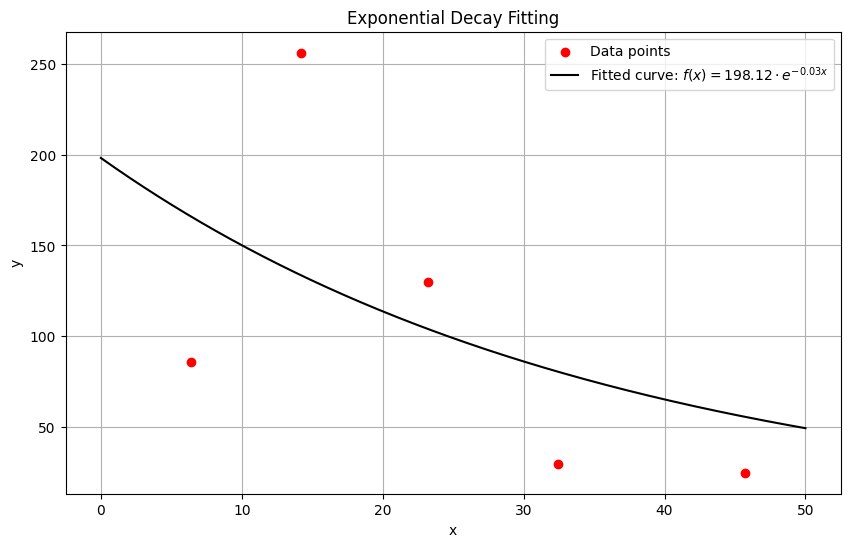

(198.12054895989766, 0.02774158270008774)

In [45]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Data points
x_data = np.array([6.38, 14.2, 23.25, 32.45, 45.7])
y_data = np.array([86, 256, 130, 30, 25])


# Define the exponential decay function
def exp_decay(x, a, b):
    return a * np.exp(-b * x)


# Perform the curve fitting
params, params_covariance = curve_fit(exp_decay, x_data, y_data, p0=[100, 0.1])

# Extract the parameters
a, b = params

# Generate fitted data for plotting
x_fit = np.linspace(0, 50, 400)
y_fit = exp_decay(x_fit, a, b)

# Plot the data points and the fitted curve
plt.figure(figsize=(10, 6))
plt.scatter(x_data, y_data, color="red", label="Data points")
plt.plot(x_fit, y_fit, label=f"Fitted curve: $f(x) = {a:.2f} \cdot e^{{-{b:.2f} x}}$", color="black")
plt.title("Exponential Decay Fitting")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True)
plt.show()

# Display the fitted parameters
a, b

In [46]:
# Test model and initial parameters


def model_func(X, a1, a2, b, c1, c2, d):
    r, refelctivity, rainrate = X
    return (
        (a1 * np.exp(-a2 * X[r]))
        + (b * X[refelctivity] / (X[r] ** 2))
        + (c1 ** X[rainrate] ** 2 + c2 * X[rainrate])
        + d
    )
    # a[0] * np.exp(-a[1] * X[r]) * b * X[refelctivity] + c * X[rainrate] # [0.34, 0.077]
    # a1 * np.exp(-a2 * X[r]) + a3 + (b1 * X[refelctivity] / (b2 * X[r])) + (c * X[rainrate])


# plot_data = regression_data[(regression_data["color"] == "white")]
plot_data = regression_data.reset_index(names="timestamp")

fig = go.Figure()
fig.add_trace(
    go.Scatter(
        x=plot_data.index,
        y=plot_data["precipitation.intensity_hour_shifted"],
        mode="lines",
        name="Rainfall Rate",
    )
)
fig.add_trace(
    go.Scatter(
        x=plot_data.index,
        y=plot_data["intensity"],
        mode="markers",
        name="Target Intensity",
        text=plot_data["target"],
        marker=dict(size=5, color=plot_data["color"]),
    )
)
fig.add_trace(
    go.Scatter(
        x=plot_data.index,
        y=model_func(
            plot_data[["range", "reflectivity", "precipitation.intensity_hour_shifted"]],
            400,
            0.1,
            20000000,
            0.8,
            -500,
            10000.0,
        ),
        mode="lines",
        name="model",
    )
)
fig.update_layout(height=800, width=1600)

In [47]:
def get_formula(coeffs, features):
    for i, (_, co) in enumerate(zip(features, coeffs)):
        for k, v in formula_map.items():
            features[i] = features[i].replace(k, v)
        features[i] = features[i].replace(" ", " \cdot ")
        features[i] = f"{co:.2f} \cdot {features[i]}"

    return f"$f(r, beta, RR) = {(' + ').join(features)}$"

In [48]:
from scipy.optimize import curve_fit

# Sample data loading
model_data = regression_data.reset_index(names="timestamp").dropna()
model_data = model_data[model_data["target"] != "Target-01"]

# Handle missing values in intensity
# model_data["intensity"].interpolate(method="linear", inplace=True)

# Prepare the data for curve fitting
X = model_data[["range", "reflectivity", "precipitation.intensity_hour_shifted"]]
y = model_data["intensity"]
formula_map = {
    "range": "r",
    "reflectivity": "beta",
    "precipitation.intensity_hour_shifted": "RR",
    "intensity": "I",
}

model_results = {}

## Curve Fitting
# Initial guess for the parameters
initial_guess = [
    400,
    0.01,
    2000000,
    0.8,
    -500,
    10000.0,
]
# Fit the model using curve_fit
params, covariance = curve_fit(model_func, X, y, p0=initial_guess, maxfev=1_000_000)  # bounds=(-100_000, 500_000))
# Extract the fitted parameters
a1, a2, b, c1, c2, d = params

# Predict the intensity using the fitted model
model_data["CurveFitting"] = model_func(X, *params)

model_results["CurveFitting"] = {
    "formula": f"$ f(r, beta, RR) = {a1:.2f} \cdot exp(-{a2:.2f}r) + {b:.2f} \cdot \cfrac{{beta}}{{r}} + {c1:.2f} \cdot RR^2 + {c2:.2f} \cdot RR + {d:.2f}$",
    "rmse": np.sqrt(mean_squared_error(y, model_data["CurveFitting"])),
    "r2": r2_score(y, model_data["CurveFitting"]),
}


## Linear Regression
lin_model = LinearRegression()
lin_model.fit(X, y)
intercept = lin_model.intercept_
coeffs = lin_model.coef_

model_data["LinearRegression"] = lin_model.predict(X)

model_results["LinearRegression"] = {
    "formula": f"$f(r, beta, RR) = {intercept:.2f} + {coeffs[0]:.2f} \cdot r + {coeffs[1]:.2f} \cdot beta + {coeffs[2]:.2f} \cdot RR$",
    "rmse": np.sqrt(mean_squared_error(y, model_data["LinearRegression"])),
    "r2": r2_score(y, model_data["LinearRegression"]),
}

## Polynomial Regression
degree = 2
poly_model = make_pipeline(PolynomialFeatures(degree), LinearRegression())
poly_model.fit(X, y)
coeffs = poly_model.named_steps["linearregression"].coef_
features = poly_model.named_steps["polynomialfeatures"].get_feature_names_out()

model_data["PolynomialRegression"] = poly_model.predict(X)

model_results["PolynomialRegression"] = {
    "formula": get_formula(coeffs, features),
    "rmse": np.sqrt(mean_squared_error(y, model_data["PolynomialRegression"])),
    "r2": r2_score(y, model_data["PolynomialRegression"]),
}

## Gradient Boosting
gb_model = GradientBoostingRegressor()
gb_model.fit(X, y)
coeffs = gb_model.feature_importances_

model_data["GradientBoosting"] = gb_model.predict(X)

model_results["GradientBoosting"] = {
    "formula": "",
    "rmse": np.sqrt(mean_squared_error(y, model_data["GradientBoosting"])),
    "r2": r2_score(y, model_data["GradientBoosting"]),
}

## Random Forest
rf_model = RandomForestRegressor()
rf_model.fit(X, y)
coeffs = rf_model.feature_importances_

model_data["RandomForest"] = rf_model.predict(X)

model_results["RandomForest"] = {
    "formula": "",
    "rmse": np.sqrt(mean_squared_error(y, model_data["RandomForest"])),
    "r2": r2_score(y, model_data["RandomForest"]),
}

# Filter the data for a specific reflectivity and range
# reflectivity_value = 0.9  # Example: white
# range_value = 32.45  # Example: 14.20 m

# filtered_model_data = model_data[(model_data["reflectivity"] == reflectivity_value) & (model_data["range"] == range_value)]


fig = make_subplots(specs=[[{"secondary_y": True}]])
fig.add_trace(
    go.Scatter(
        x=model_data.index,
        y=model_data["precipitation.intensity_hour_shifted"],
        mode="lines",
        name="Rainfall Rate",
    ),
    secondary_y=True,
)
fig.add_trace(
    go.Scatter(
        x=model_data.index,
        y=model_data["intensity"],
        mode="markers",
        name="Target Intensity",
        text=model_data["target"],
        marker=dict(size=5, color=model_data["color"]),
    )
)

for model, data in model_results.items():
    fig.add_trace(
        go.Scatter(
            x=model_data.index,
            y=model_data[model],
            mode="lines",
            name=f"Model {model}",
        )
    )

fig.update_layout(
    height=600,
    width=1600,
    yaxis2_range=[-5, 100],
    xaxis_title="Index",
    yaxis_title="Lidar Intensity",
    yaxis2_title="Rainfall Rate [mm/h]",
    yaxis2_tickmode="sync",
)

# Add linear and polynomial regression here

In [49]:
display("CurveFitting", Latex(model_results["CurveFitting"]["formula"]))
display("LinearRegression", Latex(model_results["LinearRegression"]["formula"]))
display("PolynomialRegression", Latex(model_results["PolynomialRegression"]["formula"]))
model_results

'CurveFitting'

<IPython.core.display.Latex object>

'LinearRegression'

<IPython.core.display.Latex object>

'PolynomialRegression'

<IPython.core.display.Latex object>

{'CurveFitting': {'formula': '$ f(r, beta, RR) = 5753716.57 \\cdot exp(-0.00r) + 56734187.14 \\cdot \\cfrac{beta}{r} + 1.00 \\cdot RR^2 + -1509.28 \\cdot RR + -5709924.54$',
  'rmse': 35000.40799868474,
  'r2': 0.8216080889038863},
 'LinearRegression': {'formula': '$f(r, beta, RR) = 148815.04 + -4052.26 \\cdot r + 109617.54 \\cdot beta + -1381.04 \\cdot RR$',
  'rmse': 55895.988203141394,
  'r2': 0.5450221842927515},
 'PolynomialRegression': {'formula': '$f(r, beta, RR) = 0.00 \\cdot 1 + -11980.96 \\cdot r + 312272.92 \\cdot beta + -4270.19 \\cdot RR + 188.73 \\cdot r^2 + -8142.24 \\cdot r \\cdot beta + 81.32 \\cdot r \\cdot RR + 42123.45 \\cdot beta^2 + -1666.15 \\cdot beta \\cdot RR + 38.01 \\cdot RR^2$',
  'rmse': 38381.06822050924,
  'r2': 0.7854823355905199},
 'GradientBoosting': {'formula': '',
  'rmse': 22335.819913775147,
  'r2': 0.9273504810464323},
 'RandomForest': {'formula': '',
  'rmse': 17195.290314955048,
  'r2': 0.9569425833678675}}

In [50]:
[f"{k}: {v}" for k, v in model_results.items() if v not in ["formula"]]

["CurveFitting: {'formula': '$ f(r, beta, RR) = 5753716.57 \\\\cdot exp(-0.00r) + 56734187.14 \\\\cdot \\\\cfrac{beta}{r} + 1.00 \\\\cdot RR^2 + -1509.28 \\\\cdot RR + -5709924.54$', 'rmse': 35000.40799868474, 'r2': 0.8216080889038863}",
 "LinearRegression: {'formula': '$f(r, beta, RR) = 148815.04 + -4052.26 \\\\cdot r + 109617.54 \\\\cdot beta + -1381.04 \\\\cdot RR$', 'rmse': 55895.988203141394, 'r2': 0.5450221842927515}",
 "PolynomialRegression: {'formula': '$f(r, beta, RR) = 0.00 \\\\cdot 1 + -11980.96 \\\\cdot r + 312272.92 \\\\cdot beta + -4270.19 \\\\cdot RR + 188.73 \\\\cdot r^2 + -8142.24 \\\\cdot r \\\\cdot beta + 81.32 \\\\cdot r \\\\cdot RR + 42123.45 \\\\cdot beta^2 + -1666.15 \\\\cdot beta \\\\cdot RR + 38.01 \\\\cdot RR^2$', 'rmse': 38381.06822050924, 'r2': 0.7854823355905199}",
 "GradientBoosting: {'formula': '', 'rmse': 22335.819913775147, 'r2': 0.9273504810464323}",
 "RandomForest: {'formula': '', 'rmse': 17195.290314955048, 'r2': 0.9569425833678675}"]

### Model Selection

In [51]:
# Feature Engineering
# regression_data['rainfall_rate_squared'] = df['rainfall_rate']**2
# df['range_squared'] = df['range']**2
# df['interaction'] = df['rainfall_rate'] * df['range']

# Define features and target
X = model_data[["range", "reflectivity", "precipitation.intensity_hour_shifted"]]
y = model_data["intensity"]

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)

# List of models to evaluate
models = [
    # ("Linear Regression", LinearRegression()),
    # (
    #     "Polynomial Regression (Degree 2)",
    #     make_pipeline(PolynomialFeatures(degree=2, interaction_only=False), LinearRegression()),
    # ),
    ("Random Forest Regression", RandomForestRegressor(n_estimators=100, random_state=42)),
    ("Gradient Boosting Regression", GradientBoostingRegressor(n_estimators=100, random_state=42)),
    ("Support Vector Regression", make_pipeline(StandardScaler(), SVR(kernel="rbf"))),
]

# Loop over models and evaluate
results = []
for name, model in models:
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    results.append((name, rmse, r2))

    print(f"{name} - RMSE: {rmse}, R-squared: {r2}")

    # Plot the results
    fig = go.Figure()
    fig.add_trace(
        go.Scatter(
            x=model_data.index,
            y=regression_data["precipitation.intensity_hour_shifted"],
            mode="lines",
            name="Rainfall Rate",
        )
    )
    fig.add_trace(
        go.Scatter(
            x=model_data.index,
            y=model_data["intensity"],
            mode="markers",
            name="Target Intensity",
            text=model_data["target"],
            marker=dict(size=5, color=model_data["color"]),
        )
    )
    fig.add_trace(go.Scatter(x=model_data.index, y=model.predict(X), mode="lines", name="Predicted Intensity"))
    fig.update_layout(legend_title=name)
    fig.show()


# Summarize results
for name, rmse, r2 in results:
    print(f"{name} - RMSE: {rmse:.4f}, R-squared: {r2:.4f}")

Random Forest Regression - RMSE: 31356.73031773587, R-squared: 0.8676799498580989


Gradient Boosting Regression - RMSE: 29354.671351933826, R-squared: 0.8840372355559016


Support Vector Regression - RMSE: 91200.83195984752, R-squared: -0.11933920494907335


Random Forest Regression - RMSE: 31356.7303, R-squared: 0.8677
Gradient Boosting Regression - RMSE: 29354.6714, R-squared: 0.8840
Support Vector Regression - RMSE: 91200.8320, R-squared: -0.1193
